# Full Results Comparison — All JSONs (Dynamic)

**Run on JupyterHub** from `~/FedLLM-Re/rework/notebooks/`

Fully dynamic — auto-discovers every dataset, method, alpha, and seed from whatever JSON files are present.
Reads `method`, `alpha`, `seed` from **inside** each JSON (not from filename).

In [1]:
import json, glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
# Search upward from cwd for a 'results/' directory — works whether the
# notebook is opened from rework/ or rework/notebooks/ on the server.
def _find_results():
    cwd = Path(os.getcwd())
    for candidate in [cwd / 'results',
                      cwd.parent / 'results',
                      cwd.parent.parent / 'results']:
        if candidate.is_dir():
            return candidate
    return cwd / 'results'   # best guess so error message is useful

RESULTS_DIR = _find_results()
FIGS_DIR    = RESULTS_DIR.parent / 'figures'
FIGS_DIR.mkdir(exist_ok=True)

# ── Appearance (falls back gracefully for unknown methods) ─────────────────
KNOWN_COLORS = {
    'homo_r4':    '#9e9e9e',
    'homo_r8':    '#607d8b',
    'hetero_pad': '#ff7043',
    'flexlora':   '#42a5f5',
    'hetero_spa': '#e53935',
    'spa_m':      '#6a0dad',
}
KNOWN_LABELS = {
    'homo_r4':    'FedAvg r=4',
    'homo_r8':    'FedAvg r=8',
    'hetero_pad': 'Hetero-Pad',
    'flexlora':   'FlexLoRA',
    'hetero_spa': 'SPA',
    'spa_m':      'SPA-M (Ours)',
}
KNOWN_LS = {
    'homo_r4': ':', 'homo_r8': '--',
    'hetero_pad': '-.', 'flexlora': '--', 'hetero_spa': '-.', 'spa_m': '-'
}
KNOWN_LW = {
    'homo_r4': 1.2, 'homo_r8': 1.2,
    'hetero_pad': 1.5, 'flexlora': 2.0, 'hetero_spa': 1.8, 'spa_m': 2.5
}

_FALLBACK_COLORS = ['#26a69a','#ffa726','#ab47bc','#66bb6a','#ef5350','#29b6f6']
_fallback_idx = 0

def get_color(m):
    global _fallback_idx
    if m not in KNOWN_COLORS:
        KNOWN_COLORS[m] = _FALLBACK_COLORS[_fallback_idx % len(_FALLBACK_COLORS)]
        _fallback_idx += 1
    return KNOWN_COLORS[m]

def label(m):  return KNOWN_LABELS.get(m, m)
def ls(m):     return KNOWN_LS.get(m, '-')
def lw(m):     return KNOWN_LW.get(m, 1.8)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
print(f'cwd         : {Path(os.getcwd())}')
print(f'Results dir : {RESULTS_DIR}  (exists={RESULTS_DIR.exists()})')
print(f'Figures dir : {FIGS_DIR}')

/opt/conda/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


cwd         : /home/sp2ai/FedLLM-Re/rework
Results dir : /home/sp2ai/FedLLM-Re/rework/results  (exists=True)
Figures dir : /home/sp2ai/FedLLM-Re/rework/figures


## 1. Load All Data

In [2]:
# DATA[dataset][(method, alpha)] = {'runs': [run_dict, ...]}
DATA = defaultdict(lambda: defaultdict(lambda: {'runs': []}))

# Metrics that map to 'accuracy' (normalized at load time)
ACCURACY_ALIASES = {'accuracy', 'exact_match', 'acc'}

def normalize_rounds(rounds):
    """Copy exact_match / acc → accuracy if accuracy is absent."""
    for r in rounds:
        if 'accuracy' not in r:
            for alias in ('exact_match', 'acc'):
                if alias in r:
                    r['accuracy'] = r[alias]
                    break
    return rounds

def load_all():
    total = 0
    if not RESULTS_DIR.exists():
        print(f'ERROR: {RESULTS_DIR} not found — check NB_DIR / server path')
        return

    for ds_dir in sorted(RESULTS_DIR.iterdir()):
        if not ds_dir.is_dir():
            continue
        dataset = ds_dir.name
        files = sorted(ds_dir.glob('*.json'))
        files = [f for f in files if '(' not in f.name]
        for path in files:
            try:
                with open(path) as fh:
                    d = json.load(fh)
            except Exception as e:
                print(f'  [warn] {path.name}: {e}')
                continue

            method = d.get('method')
            alpha  = d.get('alpha')
            seed   = d.get('seed')

            # Fallback: parse filename if fields are missing
            if method is None or alpha is None:
                m = re.match(r'^(.+)_seed(\d+)_alpha(\d+)\.json$', path.name)
                if m:
                    method = method or m.group(1)
                    seed   = seed   or int(m.group(2))
                    astr   = m.group(3)
                    alpha  = alpha  or ({'01': 0.1, '05': 0.5, '1': 1.0}.get(
                                         astr, float('0.' + astr)))
                else:
                    print(f'  [skip] cannot determine method/alpha: {path.name}')
                    continue

            # Dedup
            existing_seeds = {r.get('seed') for r in DATA[dataset][(method, alpha)]['runs']}
            if seed in existing_seeds:
                continue

            d['method'] = method
            d['alpha']  = alpha
            d['seed']   = seed
            d['rounds'] = normalize_rounds(d.get('rounds', []))
            DATA[dataset][(method, alpha)]['runs'].append(d)
            total += 1

    print(f'\nLoaded {total} run files\n')
    for ds in sorted(DATA):
        print(f'  [{ds}]')
        for (m, a) in sorted(DATA[ds]):
            seeds = sorted(r.get('seed') for r in DATA[ds][(m, a)]['runs'])
            # show which accuracy key was found
            sample_rounds = DATA[ds][(m, a)]['runs'][0].get('rounds', [])
            acc_key = next((k for k in ACCURACY_ALIASES
                            if sample_rounds and k in sample_rounds[0]), '?')
            print(f'    {m:<18} alpha={a}  seeds={seeds}  n={len(seeds)}  acc_key={acc_key}')

load_all()

  [skip] cannot determine method/alpha: batch_test_flexlora-checkpoint.json
  [skip] cannot determine method/alpha: batch_test_hetero_pad-checkpoint.json
  [skip] cannot determine method/alpha: batch_test_hetero_spa-checkpoint.json
  [skip] cannot determine method/alpha: batch_test_spa_m-checkpoint.json

Loaded 83 run files

  [alpaca]
    flexlora           alpha=0.5  seeds=[42, 43, 44]  n=3  acc_key=?
    hetero_pad         alpha=0.5  seeds=[42, 43, 44]  n=3  acc_key=?
    hetero_spa         alpha=0.5  seeds=[42, 43, 44]  n=3  acc_key=?
    homo_r8            alpha=0.5  seeds=[42, 43, 44]  n=3  acc_key=?
    spa_m              alpha=0.5  seeds=[42, 43, 44]  n=3  acc_key=?
  [gsm8k]
    flexlora           alpha=0.5  seeds=[42, 43, 44]  n=3  acc_key=exact_match
    hetero_pad         alpha=0.5  seeds=[42]  n=1  acc_key=exact_match
    hetero_spa         alpha=0.5  seeds=[42, 43, 44]  n=3  acc_key=exact_match
    homo_r8            alpha=0.5  seeds=[42, 43, 44]  n=3  acc_key=exact_match

## 2. Helper Functions

In [3]:
def get_curve(runs, metric, scale=1.0):
    """Align curves by round number (handles missing rounds gracefully)."""
    per_round = defaultdict(list)
    for run in runs:
        for r in run.get('rounds', []):
            if metric in r and r[metric] is not None:
                per_round[r['round']].append(r[metric] * scale)
    if not per_round:
        return np.array([]), np.array([]), np.array([])
    rounds = sorted(per_round)
    means  = np.array([np.mean(per_round[rnd]) for rnd in rounds])
    stds   = np.array([np.std( per_round[rnd]) for rnd in rounds])
    return np.array(rounds), means, stds

def final_metrics(runs, metrics):
    result = {}
    for metric in metrics:
        vals = []
        for r in runs:
            rounds = r.get('rounds', [])
            if rounds:
                v = rounds[-1].get(metric)
                if v is not None and not np.isnan(float(v)):
                    vals.append(float(v))
        result[metric] = (np.mean(vals), np.std(vals), len(vals)) if vals else (np.nan, np.nan, 0)
    return result

def best_metrics(runs, metrics):
    result = {}
    for metric in metrics:
        vals = []
        for r in runs:
            all_vals = [float(rd[metric]) for rd in r.get('rounds', [])
                        if metric in rd and rd[metric] is not None]
            if all_vals:
                vals.append(min(all_vals) if metric in LOWER_BETTER else max(all_vals))
        result[metric] = (np.mean(vals), np.std(vals), len(vals)) if vals else (np.nan, np.nan, 0)
    return result

def available_metrics(ds):
    """Return metric keys present in this dataset's rounds, deduped and ordered."""
    seen = set()
    for entry in DATA[ds].values():
        for run in entry['runs']:
            for r in run.get('rounds', []):
                seen.update(r.keys())
    # Drop non-metric fields
    for f in ('round', 'round_time_s', 'time'):
        seen.discard(f)
    # If accuracy was synthesized from exact_match, drop the alias to avoid duplication
    if 'accuracy' in seen:
        seen.discard('exact_match')
        seen.discard('acc')
    # Order: primary metric first, then other higher-is-better, then lower-is-better
    prim         = [m for m in _PRIMARY_CANDIDATES if m in seen]
    higher_other = sorted(m for m in seen if m not in LOWER_BETTER and m not in prim)
    lower        = sorted(m for m in seen if m in LOWER_BETTER)
    return prim + higher_other + lower

# Priority order for "primary" metric (accuracy-like, higher=better)
_PRIMARY_CANDIDATES = ['accuracy', 'exact_match', 'rouge_l', 'bleu', 'f1_macro', 'f1']

def primary_metric(ds):
    avail = available_metrics(ds)
    for m in _PRIMARY_CANDIDATES:
        if m in avail:
            return m
    return avail[0] if avail else 'accuracy'

METRIC_LABELS = {
    'accuracy':          'Accuracy (%)',
    'exact_match':       'Exact Match (%)',
    'f1_macro':          'F1-macro (%)',
    'f1':                'F1 (%)',
    'rouge_l':           'ROUGE-L',
    'bleu':              'BLEU',
    'hallucination_rate':'Hallucin. Rate',
    'perplexity':        'Perplexity',
    'avg_loss':          'Train Loss',
}
SCALE_100    = {'accuracy', 'exact_match', 'f1_macro', 'f1'}
LOWER_BETTER = {'perplexity', 'avg_loss', 'hallucination_rate'}

def metric_scale(m):  return 100 if m in SCALE_100 else 1
def metric_label(m):  return METRIC_LABELS.get(m, m)

def datasets_sorted():        return sorted(DATA.keys())
def methods_in(ds):           return sorted(set(m for m,_ in DATA[ds]))
def alphas_in(ds):            return sorted(set(a for _,a in DATA[ds]))
def methods_in_alpha(ds, a):  return sorted(set(m for m,aa in DATA[ds] if aa == a))

print('Helpers loaded.')

Helpers loaded.


## 3. Data Inventory Table

In [4]:
rows = []
for ds in datasets_sorted():
    for (method, alpha), entry in sorted(DATA[ds].items()):
        runs = entry['runs']
        for run in runs:
            rds = run.get('rounds', [])
            accs = [r['accuracy'] for r in rds if 'accuracy' in r]
            f1s  = [r.get('f1_macro', r.get('f1', np.nan)) for r in rds]
            rows.append({
                'dataset': ds, 'method': label(method), 'alpha': alpha,
                'seed': run.get('seed'), 'n_rounds': len(rds),
                'best_acc':  max(accs) * 100 if accs else np.nan,
                'last_acc':  accs[-1]  * 100 if accs else np.nan,
                'best_f1':   max(f1s)  * 100 if f1s  else np.nan,
            })

inv = pd.DataFrame(rows)
pd.set_option('display.max_rows', 300)
inv.style.format({'best_acc':'{:.2f}','last_acc':'{:.2f}','best_f1':'{:.2f}'}, na_rep='—')

,dataset,method,alpha,seed,n_rounds,best_acc,last_acc,best_f1
0,alpaca,FlexLoRA,0.500000,42,20,—,—,—
1,alpaca,FlexLoRA,0.500000,43,20,—,—,—
2,alpaca,FlexLoRA,0.500000,44,20,—,—,—
3,alpaca,Hetero-Pad,0.500000,42,20,—,—,—
4,alpaca,Hetero-Pad,0.500000,43,20,—,—,—
5,alpaca,Hetero-Pad,0.500000,44,20,—,—,—
6,alpaca,SPA,0.500000,42,20,—,—,—
7,alpaca,SPA,0.500000,43,20,—,—,—
8,alpaca,SPA,0.500000,44,20,—,—,—
9,alpaca,FedAvg r=8,0.500000,42,20,—,—,—


In [5]:
# ── Missing Results Audit ─────────────────────────────────────────────────
# For each dataset, infer the "expected" full grid (all methods × all seeds × all alphas)
# and report what is absent.

missing = []
for ds in datasets_sorted():
    all_methods = methods_in(ds)
    all_alphas  = alphas_in(ds)
    all_seeds   = sorted(set(
        r['seed']
        for entry in DATA[ds].values()
        for r in entry['runs']
    ))
    for method in all_methods:
        for alpha in all_alphas:
            for seed in all_seeds:
                key  = (method, alpha)
                have = key in DATA[ds] and any(
                    r['seed'] == seed for r in DATA[ds][key]['runs'])
                if not have:
                    missing.append({'dataset': ds, 'method': label(method),
                                    'alpha': alpha, 'seed': seed})

if missing:
    df_miss = pd.DataFrame(missing)
    print(f'{len(missing)} missing run(s):\n')
    print(df_miss.to_string(index=False))
else:
    print('No missing results — grid is complete!')

4 missing run(s):

dataset     method  alpha  seed
  gsm8k Hetero-Pad    0.5    43
  gsm8k Hetero-Pad    0.5    44
   yelp FedAvg r=4    0.1    42
   yelp FedAvg r=8    0.1    42


## 4. Convergence Curves — Accuracy & F1 (all datasets × all alphas)

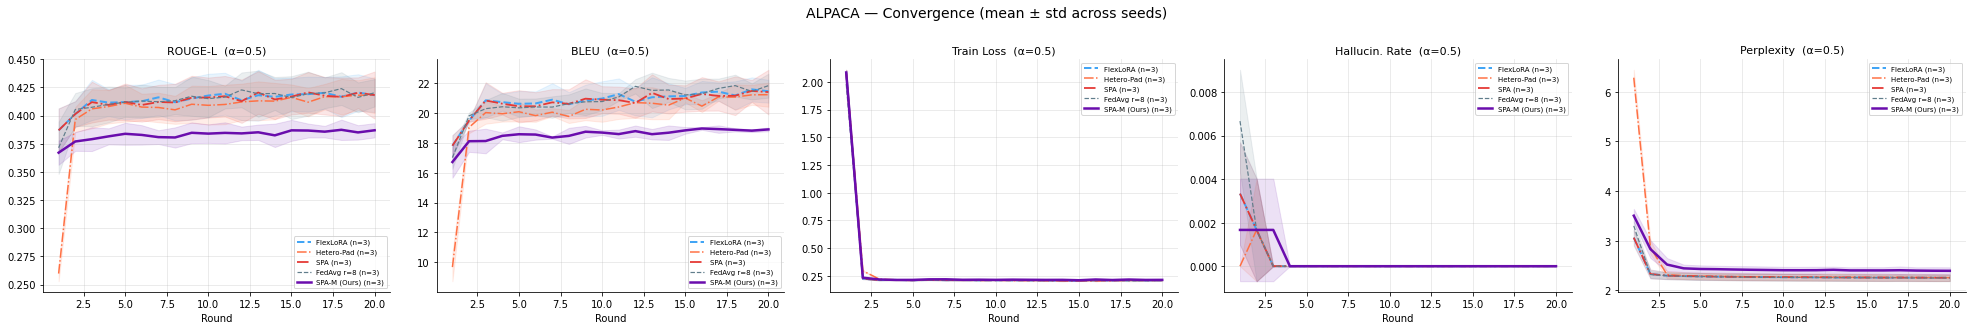

Saved → alpaca_convergence_all.pdf


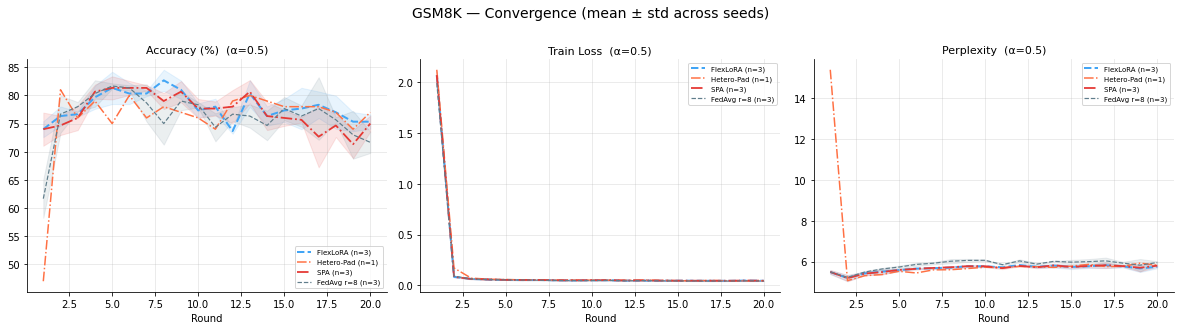

Saved → gsm8k_convergence_all.pdf


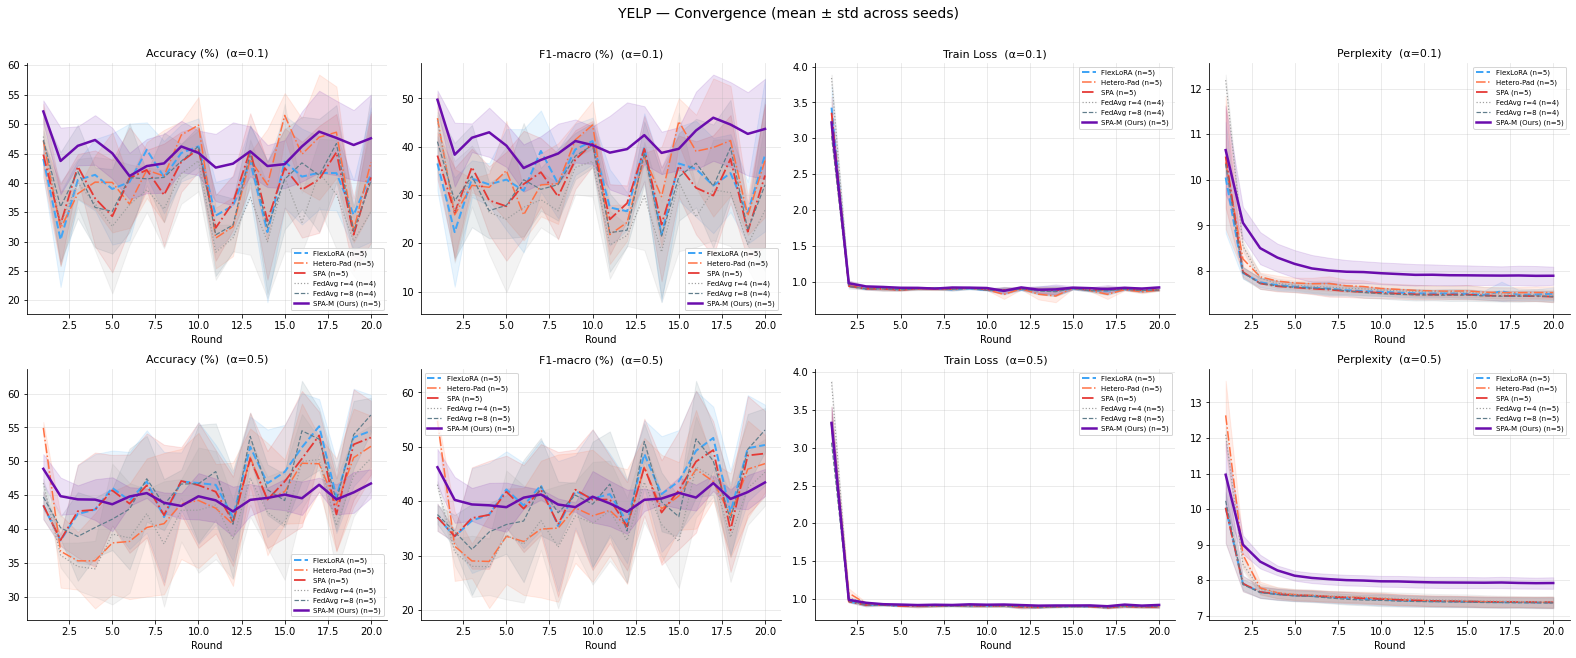

Saved → yelp_convergence_all.pdf


In [6]:
for ds in datasets_sorted():
    alphas  = alphas_in(ds)
    methods = methods_in(ds)
    # Build metric list from whatever keys actually exist in this dataset's rounds
    ds_metrics = available_metrics(ds)
    active = [(m, metric_label(m), metric_scale(m)) for m in ds_metrics]

    if not active or not alphas:
        print(f'[{ds}] no data to plot')
        continue

    ncols = len(active)
    nrows = len(alphas)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows), squeeze=False)
    fig.suptitle(f'{ds.upper()} — Convergence (mean ± std across seeds)', fontsize=14, y=1.01)

    for row_i, alpha in enumerate(alphas):
        for col_i, (metric, mlab, scale) in enumerate(active):
            ax = axes[row_i][col_i]
            for method in methods:
                key = (method, alpha)
                if key not in DATA[ds]:
                    continue
                runs = DATA[ds][key]['runs']
                rnds, means, stds = get_curve(runs, metric, scale=scale)
                if len(rnds) == 0:
                    continue
                n = len(runs)
                color = get_color(method)
                ax.plot(rnds, means,
                        label=f"{label(method)} (n={n})",
                        color=color, linestyle=ls(method), linewidth=lw(method))
                if n > 1:
                    ax.fill_between(rnds, means-stds, means+stds, alpha=0.12, color=color)
                if metric in LOWER_BETTER:
                    ax.invert_yaxis() if col_i == 0 and row_i == 0 else None
            ax.set_title(f'{mlab}  (α={alpha})', fontsize=11)
            ax.set_xlabel('Round')
            ax.legend(fontsize=7, ncol=1)
            ax.grid(True, alpha=0.3)
            ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    out = FIGS_DIR / f'{ds}_convergence_all.pdf'
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out.name}')

## 5. Summary Table — Best & Final Round (all datasets)

In [7]:
for ds in datasets_sorted():
    ds_metrics = available_metrics(ds)
    # Column width = max of header length and value length, minimum 14
    col_w = max(14, max(len(metric_label(m)) for m in ds_metrics) + 2)
    val_fmt = f'{{:>{col_w}.3f}}'

    for alpha in alphas_in(ds):
        methods = methods_in_alpha(ds, alpha)

        rows = {}
        for method in methods:
            key = (method, alpha)
            if key in DATA[ds]:
                rows[method] = final_metrics(DATA[ds][key]['runs'], ds_metrics)

        best = {}
        for metric in ds_metrics:
            vals = [(m, rows[m][metric][0]) for m in rows if not np.isnan(rows[m][metric][0])]
            if vals:
                best[metric] = (min if metric in LOWER_BETTER else max)(
                    vals, key=lambda x: x[1])[0]

        header = f"{'Method':<20}" + ''.join(f"{metric_label(m):>{col_w}}" for m in ds_metrics) + '  n'
        sep = '=' * len(header)
        print(f'\n{sep}')
        print(f'{ds.upper()} — α={alpha} — Final Round (mean ± std over seeds)')
        print(sep)
        print(header)
        print('-' * len(header))

        for method in methods:
            if method not in rows:
                continue
            fm = rows[method]
            cells = []
            for metric in ds_metrics:
                mean, std, _ = fm[metric]
                s = metric_scale(metric)
                if np.isnan(mean):
                    cells.append(f"{'—':>{col_w}}")
                else:
                    tag = '*' if best.get(metric) == method else ' '
                    val_str = f"{mean*s:.3f}±{std*s:.3f}{tag}"
                    cells.append(f"{val_str:>{col_w}}")
            n = len(DATA[ds][(method, alpha)]['runs'])
            marker = ' <<<' if method == 'spa_m' else ''
            print(f"{label(method):<20}{''.join(cells)}  {n}{marker}")

print('\n* = best in column')


ALPACA — α=0.5 — Final Round (mean ± std over seeds)
Method                       ROUGE-L            BLEU      Train Loss  Hallucin. Rate      Perplexity  n
-------------------------------------------------------------------------------------------------------
FlexLoRA                0.418±0.015    21.471±0.765     0.210±0.002     0.000±0.000*    2.254±0.065   3
Hetero-Pad              0.418±0.016    21.239±0.807     0.210±0.002     0.000±0.000     2.257±0.066   3
SPA                     0.418±0.021    21.413±1.496     0.210±0.002     0.000±0.000     2.255±0.066   3
FedAvg r=8              0.420±0.012*   21.845±0.804*    0.208±0.003*    0.000±0.000     2.251±0.066*  3
SPA-M (Ours)            0.387±0.006    18.911±0.126     0.214±0.004     0.000±0.000     2.395±0.071   3 <<<

GSM8K — α=0.5 — Final Round (mean ± std over seeds)
Method                Accuracy (%)    Train Loss    Perplexity  n
-----------------------------------------------------------------
FlexLoRA             75.333±1

## 6. Bar Chart — Final Accuracy, All Methods (per dataset)

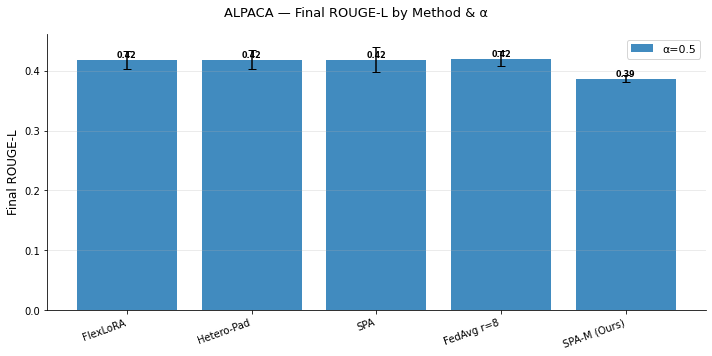

Saved → alpaca_bar_primary_metric.pdf  (metric: rouge_l)


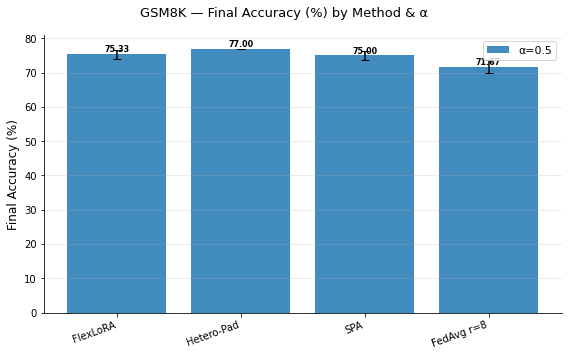

Saved → gsm8k_bar_primary_metric.pdf  (metric: accuracy)


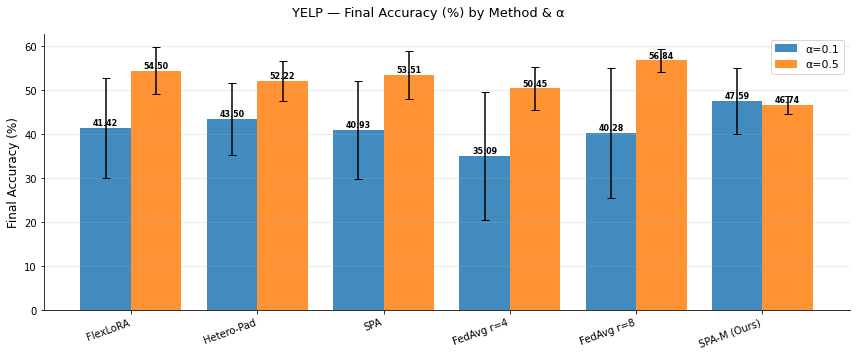

Saved → yelp_bar_primary_metric.pdf  (metric: accuracy)


In [8]:
for ds in datasets_sorted():
    alphas  = alphas_in(ds)
    methods = methods_in(ds)
    pmetric = primary_metric(ds)     # dataset-specific primary metric
    scale   = metric_scale(pmetric)
    ylabel  = f'Final {metric_label(pmetric)}'
    if not methods or not alphas:
        continue

    x     = np.arange(len(methods))
    width = 0.8 / len(alphas)

    fig, ax = plt.subplots(figsize=(max(8, 2*len(methods)), 5))
    fig.suptitle(f'{ds.upper()} — Final {metric_label(pmetric)} by Method & α', fontsize=13)

    for i, alpha in enumerate(alphas):
        means, errs = [], []
        for method in methods:
            key = (method, alpha)
            if key in DATA[ds]:
                fm = final_metrics(DATA[ds][key]['runs'], [pmetric])
                m, s, _ = fm[pmetric]
                means.append(m * scale if not np.isnan(m) else 0)
                errs.append(s  * scale if not np.isnan(s) else 0)
            else:
                means.append(0); errs.append(0)
        offset = (i - len(alphas)/2 + 0.5) * width
        bars = ax.bar(x + offset, means, width,
                      label=f'α={alpha}', yerr=errs, capsize=4, alpha=0.85)
        for bar, val in zip(bars, means):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001*max(means),
                        f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([label(m) for m in methods], rotation=20, ha='right', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    out = FIGS_DIR / f'{ds}_bar_primary_metric.pdf'
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out.name}  (metric: {pmetric})')

## 7. Alpha Comparison — Does α matter? (per dataset × method)

[alpaca] only one alpha — skipping alpha comparison
[gsm8k] only one alpha — skipping alpha comparison


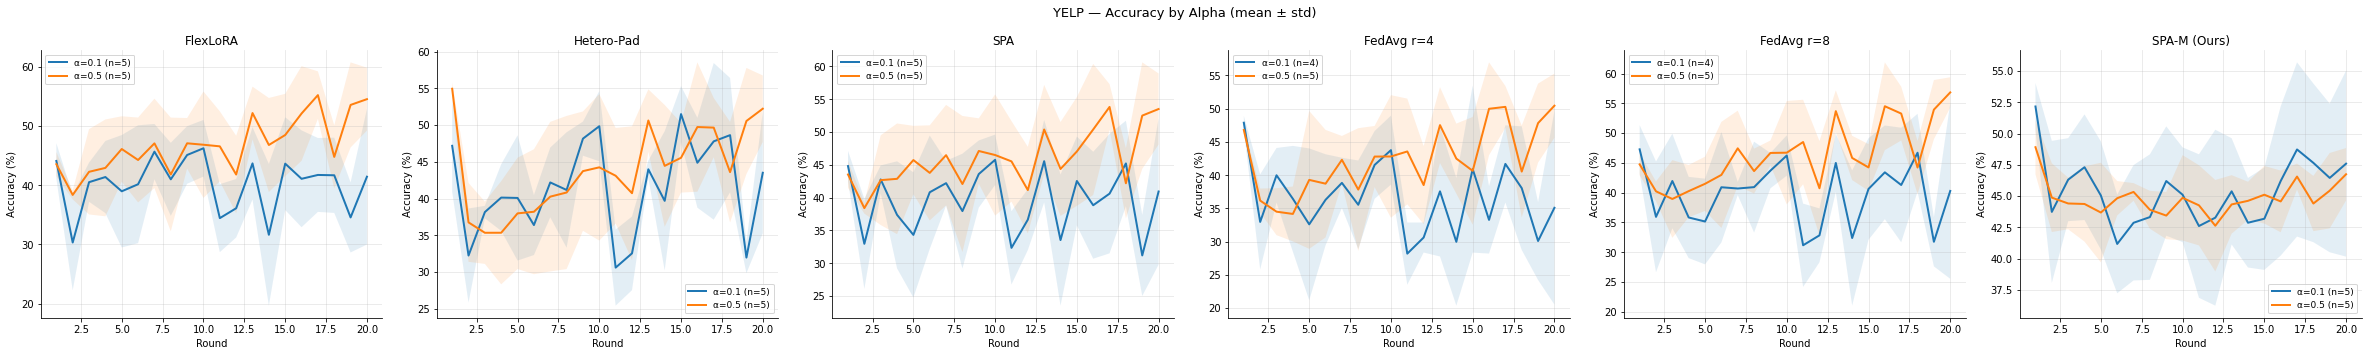

Saved → yelp_alpha_comparison.pdf


In [9]:
for ds in datasets_sorted():
    alphas = alphas_in(ds)
    if len(alphas) < 2:
        print(f'[{ds}] only one alpha — skipping alpha comparison')
        continue

    # Methods present in at least 2 alphas
    methods = [m for m in methods_in(ds)
               if sum(1 for a in alphas if (m,a) in DATA[ds]) >= 2]
    if not methods:
        print(f'[{ds}] no methods span multiple alphas')
        continue

    fig, axes = plt.subplots(1, len(methods),
                              figsize=(5.5*len(methods), 5), squeeze=False)
    fig.suptitle(f'{ds.upper()} — Accuracy by Alpha (mean ± std)', fontsize=13)

    for col_i, method in enumerate(methods):
        ax = axes[0][col_i]
        for alpha in alphas:
            key = (method, alpha)
            if key not in DATA[ds]:
                continue
            runs = DATA[ds][key]['runs']
            rnds, means, stds = get_curve(runs, 'accuracy', scale=100)
            if len(rnds) == 0:
                continue
            n = len(runs)
            ax.plot(rnds, means, label=f'α={alpha} (n={n})', linewidth=2.0)
            if n > 1:
                ax.fill_between(rnds, means-stds, means+stds, alpha=0.12)
        ax.set_title(label(method))
        ax.set_xlabel('Round')
        ax.set_ylabel('Accuracy (%)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    out = FIGS_DIR / f'{ds}_alpha_comparison.pdf'
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out.name}')

## 8. Cross-Dataset Comparison (α=0.5, shared methods)

/tmp/ipykernel_9013/145374918.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


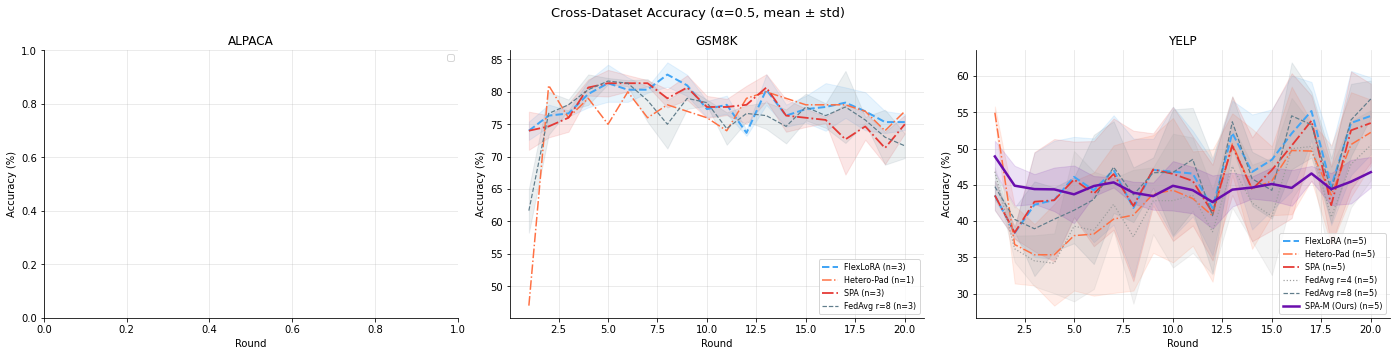

Saved → cross_dataset_alpha05.pdf


In [10]:
alpha = 0.5
ds_with_data = [ds for ds in datasets_sorted() if any(a == alpha for _,a in DATA[ds])]

if len(ds_with_data) < 2:
    print(f'Only {len(ds_with_data)} dataset(s) have α={alpha} data — skipping cross-dataset plot')
else:
    fig, axes = plt.subplots(1, len(ds_with_data),
                              figsize=(6.5*len(ds_with_data), 5), squeeze=False)
    fig.suptitle(f'Cross-Dataset Accuracy (α={alpha}, mean ± std)', fontsize=13)

    for col_i, ds in enumerate(ds_with_data):
        ax = axes[0][col_i]
        for method in methods_in_alpha(ds, alpha):
            key = (method, alpha)
            runs = DATA[ds][key]['runs']
            rnds, means, stds = get_curve(runs, 'accuracy', scale=100)
            if len(rnds) == 0:
                continue
            n = len(runs)
            color = get_color(method)
            ax.plot(rnds, means,
                    label=f"{label(method)} (n={n})",
                    color=color, linestyle=ls(method), linewidth=lw(method))
            if n > 1:
                ax.fill_between(rnds, means-stds, means+stds, alpha=0.12, color=color)
        ax.set_title(ds.upper())
        ax.set_xlabel('Round')
        ax.set_ylabel('Accuracy (%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    out = FIGS_DIR / f'cross_dataset_alpha{str(alpha).replace(".","")}.pdf'
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out.name}')

## 9. SPA vs FlexLoRA — Per-Seed Scatter

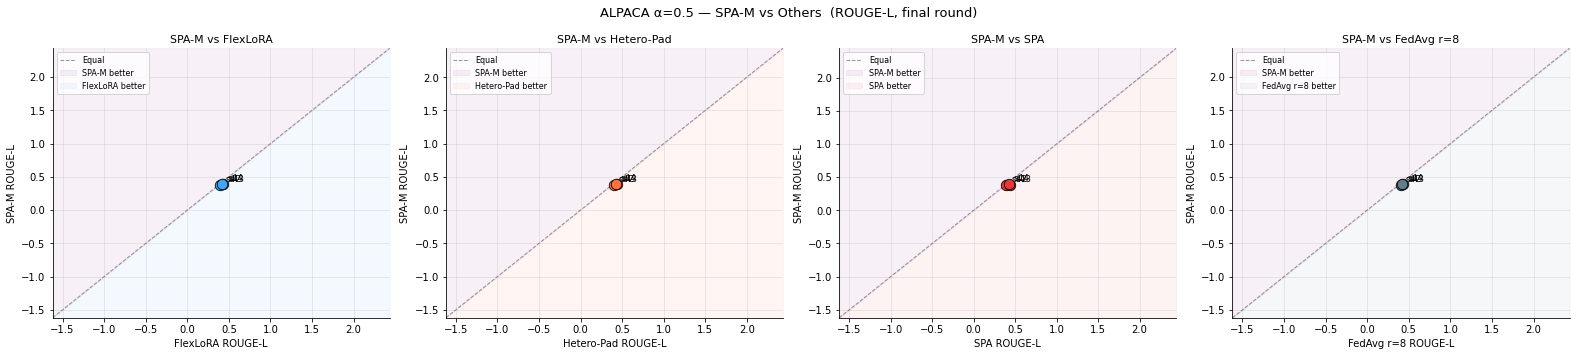

Saved → alpaca_alpha05_scatter_spam_vs_all.pdf
[gsm8k α=0.5] no SPA-M results — skipping scatter


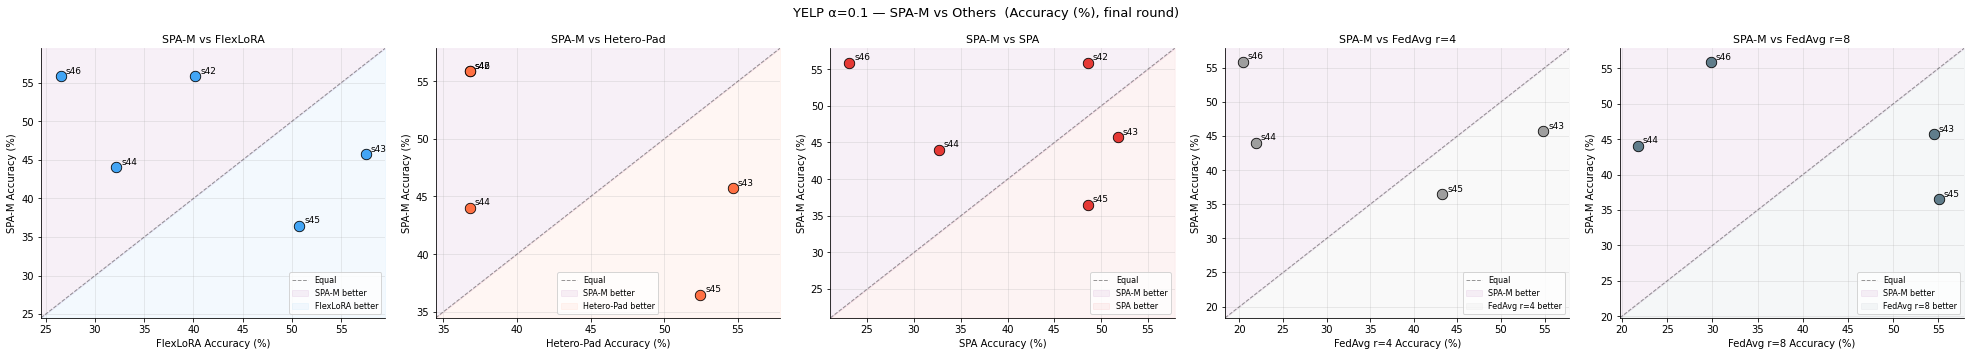

Saved → yelp_alpha01_scatter_spam_vs_all.pdf


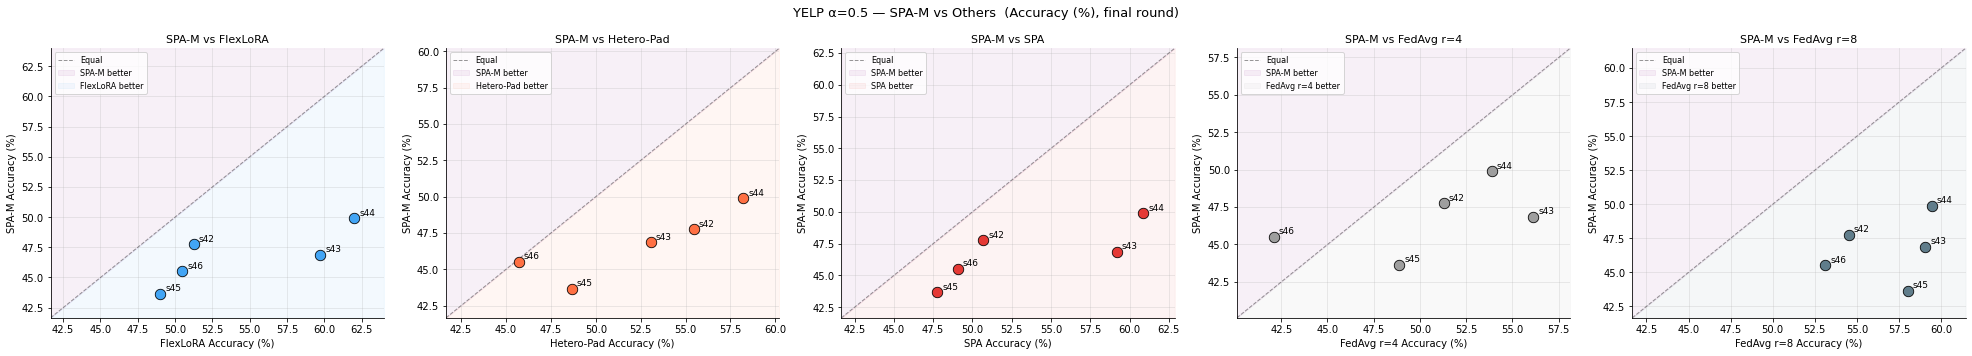

Saved → yelp_alpha05_scatter_spam_vs_all.pdf


In [11]:
pmetric = primary_metric('yelp')   # use per-dataset primary metric inside loop

for ds in datasets_sorted():
    pm     = primary_metric(ds)
    scale  = metric_scale(pm)

    for alpha in alphas_in(ds):
        if ('spa_m', alpha) not in DATA[ds]:
            print(f'[{ds} α={alpha}] no SPA-M results — skipping scatter')
            continue

        # All methods to compare against SPA-M (everyone except spa_m itself)
        others = [m for m in methods_in_alpha(ds, alpha) if m != 'spa_m']
        if not others:
            continue

        # Build SPA-M final-round values per seed
        spa_m_vals = {
            r['seed']: (r['rounds'][-1].get(pm, np.nan) or np.nan) * scale
            for r in DATA[ds][('spa_m', alpha)]['runs'] if r.get('rounds')
        }

        # Filter to methods that share at least one seed with SPA-M
        plot_methods = [m for m in others
                        if (m, alpha) in DATA[ds] and
                        set(r['seed'] for r in DATA[ds][(m, alpha)]['runs']) & set(spa_m_vals)]
        if not plot_methods:
            print(f'[{ds} α={alpha}] no shared seeds with SPA-M — skipping')
            continue

        ncols = len(plot_methods)
        fig, axes = plt.subplots(1, ncols, figsize=(5.5*ncols, 5), squeeze=False)
        fig.suptitle(
            f'{ds.upper()} α={alpha} — SPA-M vs Others  ({metric_label(pm)}, final round)',
            fontsize=13)

        for col_i, method in enumerate(plot_methods):
            ax = axes[0][col_i]

            other_vals = {
                r['seed']: (r['rounds'][-1].get(pm, np.nan) or np.nan) * scale
                for r in DATA[ds][(method, alpha)]['runs'] if r.get('rounds')
            }
            seeds = sorted(set(spa_m_vals) & set(other_vals))
            if not seeds:
                ax.set_title(f'{label(method)}\nno shared seeds')
                continue

            y = [spa_m_vals[s]  for s in seeds]   # SPA-M on Y
            x = [other_vals[s]  for s in seeds]   # other on X

            color = get_color(method)
            ax.scatter(x, y, s=110, zorder=5, color=color,
                       edgecolors='black', linewidth=0.8)
            for i, s in enumerate(seeds):
                ax.annotate(f's{s}', (x[i], y[i]),
                            textcoords='offset points', xytext=(5, 3), fontsize=9)

            all_vals = x + y
            lo = min(all_vals) - 2
            hi = max(all_vals) + 2
            lims = [lo, hi]
            ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1, label='Equal')
            ax.fill_between(lims, lims, [hi]*2, alpha=0.06,
                            color='purple', label='SPA-M better')
            ax.fill_between(lims, [lo]*2, lims, alpha=0.06,
                            color=color,   label=f'{label(method)} better')
            ax.set_xlim(lims); ax.set_ylim(lims)
            ax.set_xlabel(f'{label(method)} {metric_label(pm)}', fontsize=10)
            ax.set_ylabel(f'SPA-M {metric_label(pm)}', fontsize=10)
            ax.set_title(f'SPA-M vs {label(method)}', fontsize=11)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.spines[['top','right']].set_visible(False)

        plt.tight_layout()
        out = FIGS_DIR / f'{ds}_alpha{str(alpha).replace(".","")}_scatter_spam_vs_all.pdf'
        plt.savefig(out, bbox_inches='tight')
        plt.show()
        print(f'Saved → {out.name}')

## 10. Per-Seed Stability Table

In [12]:
for ds in datasets_sorted():
    pmetric = primary_metric(ds)
    scale   = metric_scale(pmetric)

    for alpha in alphas_in(ds):
        methods = methods_in_alpha(ds, alpha)
        all_seeds = sorted(set(
            r['seed'] for m in methods
            for r in DATA[ds].get((m, alpha), {}).get('runs', [])
        ))
        stab_rows = []
        for method in methods:
            key = (method, alpha)
            if key not in DATA[ds]:
                continue
            seed_bests = {}
            for run in DATA[ds][key]['runs']:
                rds = run.get('rounds', [])
                vals = [float(r[pmetric]) for r in rds if pmetric in r and r[pmetric] is not None]
                if vals:
                    seed_bests[run['seed']] = (min(vals) if pmetric in LOWER_BETTER else max(vals)) * scale
            if not seed_bests:
                continue
            vals = list(seed_bests.values())
            row = {'Method': label(method)}
            for s in all_seeds:
                row[f's{s}'] = f"{seed_bests[s]:.3f}" if s in seed_bests else '—'
            row['mean'] = f'{np.mean(vals):.3f}'
            row['std']  = f'{np.std(vals):.3f}'
            row['min']  = f'{min(vals):.3f}'
            row['max']  = f'{max(vals):.3f}'
            stab_rows.append(row)

        if not stab_rows:
            continue
        print(f'\n=== {ds.upper()} α={alpha} — Per-seed best {metric_label(pmetric)} ===')
        print(pd.DataFrame(stab_rows).fillna('—').to_string(index=False))


=== ALPACA α=0.5 — Per-seed best ROUGE-L ===
      Method   s42   s43   s44  mean   std   min   max
    FlexLoRA 0.400 0.442 0.432 0.425 0.018 0.400 0.442
  Hetero-Pad 0.401 0.435 0.427 0.421 0.014 0.401 0.435
         SPA 0.401 0.442 0.429 0.424 0.017 0.401 0.442
  FedAvg r=8 0.405 0.442 0.428 0.425 0.015 0.405 0.442
SPA-M (Ours) 0.380 0.392 0.400 0.390 0.008 0.380 0.400

=== GSM8K α=0.5 — Per-seed best Accuracy (%) ===
    Method    s42    s43    s44   mean   std    min    max
  FlexLoRA 84.000 85.000 83.000 84.000 0.816 83.000 85.000
Hetero-Pad 81.000      —      — 81.000 0.000 81.000 81.000
       SPA 82.000 84.000 82.000 82.667 0.943 82.000 84.000
FedAvg r=8 83.000 83.000 82.000 82.667 0.471 82.000 83.000

=== YELP α=0.1 — Per-seed best Accuracy (%) ===
      Method    s42    s43    s44    s45    s46   mean   std    min    max
    FlexLoRA 49.660 57.480 54.160 51.100 54.520 53.384 2.748 49.660 57.480
  Hetero-Pad 56.380 54.660 56.380 55.740 56.380 55.908 0.671 54.660 56.380
     

## 11. LaTeX Table (ready to paste into paper)

In [13]:
for ds in datasets_sorted():
    alphas   = sorted(alphas_in(ds), reverse=True)
    methods  = methods_in(ds)
    ds_metrics = available_metrics(ds)
    if not methods:
        continue

    # Collect data
    table = {}
    for method in methods:
        table[method] = {}
        for alpha in alphas:
            key = (method, alpha)
            if key in DATA[ds]:
                table[method][alpha] = final_metrics(DATA[ds][key]['runs'], ds_metrics)

    n_metric_cols = len(ds_metrics)
    n_alpha_cols  = len(alphas) * n_metric_cols
    col_spec = 'l' + 'r' * n_alpha_cols

    # Short labels for LaTeX header
    short = {'accuracy':'Acc.','exact_match':'EM','f1_macro':'F1','rouge_l':'R-L',
             'bleu':'BLEU','hallucination_rate':'Hall.','perplexity':'PPL','avg_loss':'Loss'}
    metric_short = lambda m: short.get(m, m[:4]+'.')

    print(f'% {"-"*60}')
    print(f'% Table: {ds.upper()} Results  (metrics: {", ".join(ds_metrics)})')
    print(f'% {"-"*60}')
    print(r'\begin{table}[h]')
    print(r'\centering')
    print(f'\\begin{{tabular}}{{{col_spec}}}')
    print(r'\toprule')

    alpha_hdr = ' & '.join(
        f'\\multicolumn{{{n_metric_cols}}}{{c}}{{$\\alpha={a}$}}' for a in alphas)
    cmidrules = ' '.join(
        f'\\cmidrule(lr){{{2+i*n_metric_cols}-{1+(i+1)*n_metric_cols}}}'
        for i in range(len(alphas)))
    metric_hdr = ' & '.join(' & '.join(metric_short(m) for m in ds_metrics) for _ in alphas)

    print(f' & {alpha_hdr} \\\\')
    print(cmidrules)
    print(f'Method & {metric_hdr} \\\\')
    print(r'\midrule')

    for method in methods:
        cells = []
        for alpha in alphas:
            fm = table[method].get(alpha, {})
            for metric in ds_metrics:
                if not fm or np.isnan(fm[metric][0]):
                    cells.append('—')
                else:
                    mean, std, _ = fm[metric]
                    s = metric_scale(metric)
                    cells.append(f'{mean*s:.3f}$_{{\\pm {std*s:.3f}}}$')
        row = f'{label(method)} & ' + ' & '.join(cells) + r' \\'
        if method == 'hetero_spa':
            row = r'\rowcolor{gray!15} ' + row
        print(row)

    print(r'\bottomrule')
    print(r'\end{tabular}')
    print(f'\\caption{{{ds.upper()} results. Mean $\\pm$ std over seeds.}}')
    print(f'\\label{{tab:{ds}}}')
    print(r'\end{table}')
    print()

% ------------------------------------------------------------
% Table: ALPACA Results  (metrics: rouge_l, bleu, avg_loss, hallucination_rate, perplexity)
% ------------------------------------------------------------
\begin{table}[h]
\centering
\begin{tabular}{lrrrrr}
\toprule
 & \multicolumn{5}{c}{$\alpha=0.5$} \\
\cmidrule(lr){2-6}
Method & R-L & BLEU & Loss & Hall. & PPL \\
\midrule
FlexLoRA & 0.418$_{\pm 0.015}$ & 21.471$_{\pm 0.765}$ & 0.210$_{\pm 0.002}$ & 0.000$_{\pm 0.000}$ & 2.254$_{\pm 0.065}$ \\
Hetero-Pad & 0.418$_{\pm 0.016}$ & 21.239$_{\pm 0.807}$ & 0.210$_{\pm 0.002}$ & 0.000$_{\pm 0.000}$ & 2.257$_{\pm 0.066}$ \\
\rowcolor{gray!15} SPA & 0.418$_{\pm 0.021}$ & 21.413$_{\pm 1.496}$ & 0.210$_{\pm 0.002}$ & 0.000$_{\pm 0.000}$ & 2.255$_{\pm 0.066}$ \\
FedAvg r=8 & 0.420$_{\pm 0.012}$ & 21.845$_{\pm 0.804}$ & 0.208$_{\pm 0.003}$ & 0.000$_{\pm 0.000}$ & 2.251$_{\pm 0.066}$ \\
SPA-M (Ours) & 0.387$_{\pm 0.006}$ & 18.911$_{\pm 0.126}$ & 0.214$_{\pm 0.004}$ & 0.000$_{\pm 0.000}

## 12. Grand Summary CSV

In [14]:
grand = []
for ds in datasets_sorted():
    ds_metrics = available_metrics(ds)
    for alpha in alphas_in(ds):
        for method in methods_in_alpha(ds, alpha):
            key   = (method, alpha)
            runs  = DATA[ds][key]['runs']
            fm    = final_metrics(runs, ds_metrics)
            bm    = best_metrics(runs, ds_metrics)
            seeds = sorted(r.get('seed') for r in runs)
            row   = {
                'dataset': ds, 'method': label(method),
                'alpha': alpha, 'n': len(runs), 'seeds': str(seeds),
            }
            for metric in ds_metrics:
                s = metric_scale(metric)
                f_mean, f_std, _ = fm[metric]
                b_mean, b_std, _ = bm[metric]
                row[f'final_{metric}_mean'] = round(f_mean * s, 4) if not np.isnan(f_mean) else None
                row[f'final_{metric}_std']  = round(f_std  * s, 4) if not np.isnan(f_std)  else None
                row[f'best_{metric}_mean']  = round(b_mean * s, 4) if not np.isnan(b_mean) else None
                row[f'best_{metric}_std']   = round(b_std  * s, 4) if not np.isnan(b_std)  else None
            grand.append(row)

df_grand = pd.DataFrame(grand)
print('=== GRAND SUMMARY ===')
# Show a condensed view grouped by dataset
for ds in datasets_sorted():
    sub = df_grand[df_grand.dataset == ds]
    print(f'\n[{ds.upper()}]')
    print(sub.to_string(index=False))

out = FIGS_DIR / 'grand_summary.csv'
df_grand.to_csv(out, index=False)
print(f'\nSaved → {out.name}')

=== GRAND SUMMARY ===

[ALPACA]
dataset       method  alpha  n        seeds  final_rouge_l_mean  final_rouge_l_std  best_rouge_l_mean  best_rouge_l_std  final_bleu_mean  final_bleu_std  best_bleu_mean  best_bleu_std  final_avg_loss_mean  final_avg_loss_std  best_avg_loss_mean  best_avg_loss_std  final_hallucination_rate_mean  final_hallucination_rate_std  best_hallucination_rate_mean  best_hallucination_rate_std  final_perplexity_mean  final_perplexity_std  best_perplexity_mean  best_perplexity_std  final_accuracy_mean  final_accuracy_std  best_accuracy_mean  best_accuracy_std  final_f1_macro_mean  final_f1_macro_std  best_f1_macro_mean  best_f1_macro_std
 alpaca     FlexLoRA    0.5  3 [42, 43, 44]              0.4180             0.0149             0.4248            0.0178          21.4709          0.7648         21.8310         0.8962               0.2098              0.0017              0.2031             0.0015                            0.0                           0.0            